# 📊 Exploratory Data Analysis (EDA)
## HR Employee Attrition Dataset

This notebook performs Exploratory Data Analysis (EDA) on the **HR Employee Attrition dataset** and directly supports the overall project documented in the README file.

The analysis aligns with the project objectives, business requirements, and hypotheses outlined in the README, ensuring consistency across the full data analytics lifecycle. fileciteturn4file0

### Project Context (from README)
- Identify key drivers of employee attrition
- Analyse attrition trends across departments and roles
- Assess impact of salary and satisfaction
- Provide actionable retention insights

This notebook specifically delivers the **EDA phase** of the project plan.


## Load Data


## Alignment to README

This notebook follows the structure defined in the project README and supports:

**Project Plan Stage:** Exploratory Data Analysis (EDA)

**Hypotheses being explored:**
- H1: Low job satisfaction increases attrition
- H2: Lower income increases attrition
- H3: Poor work-life balance increases attrition

**Visualisation Mapping:**
- Histograms → Workforce distribution
- Box plots → Income vs attrition
- Count plots → Satisfaction and department trends
- Heatmap → Correlation analysis

This ensures consistency between the README, analysis, and dashboard outputs.


## Dataset Reference

This project uses the **HR Employee Attrition dataset**, commonly used for HR analytics and workforce retention analysis.

It represents a **static snapshot of employee data**, meaning:
- It is suitable for identifying patterns and relationships
- It does not capture trends over time

The dataset has been sourced for educational and analytical purposes and contains no personally identifiable information.


---

# Change working directory

   
To make relative file paths work correctly, we move from the notebook folder to the project root.


In [35]:
import os

current_dir = os.getcwd()
current_dir


'c:\\Python Projects\\Employee_attrition_analysis3'

In [36]:
import os
from pathlib import Path

# Navigate to project root by detecting the Dataset folder
project_root_candidates = [
    Path.cwd(),
    Path.cwd() / "Employee_attrition_analysis3",
    Path.cwd().parent / "Employee_attrition_analysis3"
]
project_root = next((path for path in project_root_candidates if (path / "Dataset").exists()), None)

if project_root is None:
    raise FileNotFoundError("Could not locate the project root containing the Dataset folder.")

os.chdir(project_root)
print(f"Working directory updated to project root: {os.getcwd()}")

Working directory updated to project root: c:\Python Projects\Employee_attrition_analysis3


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Dataset/Processed/hr_employee_attrition_cleaned.csv")


df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Data Overview


In [38]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

There is no missing data 

In [ ]:
df.describe()


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


Explanation

Displays statistical summary of numerical columns
Includes count, mean, standard deviation, minimum, and maximum values

Key Observations

All columns have 1470 values, confirming no missing data
The average employee age is around 37 years
Employees have an average of 11 years of total work experience
The average time at the company is about 7 years
Some columns (e.g., EmployeeCount, StandardHours) have constant values and may not be useful
There is variation in income and experience across employees


I used df.describe() to understand the main statistics of the dataset, such as age, experience, and salary patterns.



## Target Variable Distribution (Attrition)


Explanation

Counts the number of employees in each category of the Attrition column
Shows how many employees left (Yes) and stayed (No)

Key Observations
Most employees have not left the company (No)
A smaller number of employees have left (Yes)
This indicates that the dataset may be imbalanced


I checked how many employees left the company and how many stayed.

In [ ]:
df['Attrition'].value_counts()


Attrition
No     1233
Yes     237
Name: count, dtype: int64

Output
No: 1233
Yes: 237

Explanation
Counts the number of employees who stayed (No) and left (Yes)
Shows the distribution of the target variable

Key Observations
A large majority of employees (1233) stayed with the company
A smaller number (237) left the company
This indicates that the dataset is imbalanced, with more employees staying than leaving


I checked how many employees left and stayed, and found that most employees stayed.

Explanation

sns.countplot() creates a bar chart showing the count of each category
 in Attrition
The x-axis represents whether employees left (Yes) or stayed (No)
plt.title() adds a title to the chart
plt.show() displays the plot

Key Observations

The bar for "No" is much higher than "Yes"
This confirms that most employees stayed, while fewer left
The dataset is imbalanced


I created a bar chart to visually show how many employees left and stayed.

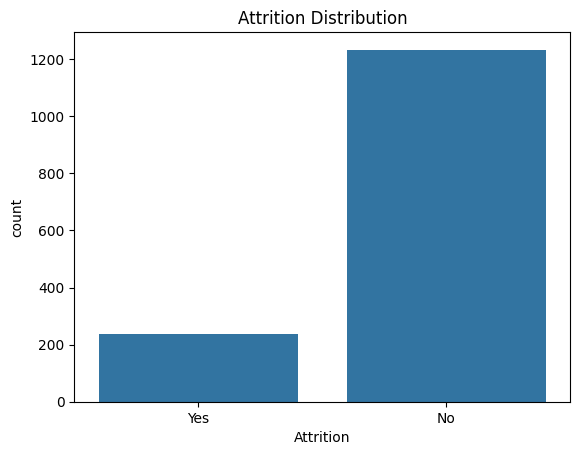

In [41]:
sns.countplot(data=df, x='Attrition')
plt.title('Attrition Distribution')
plt.show()


Attrition Distribution (Visualisation)


### Explanation

The bar chart shows the number of employees who stayed (`No`) and those who left (`Yes`).

### Key Observations

- A large majority of employees (**around 1233**) stayed with the company  
- A smaller number (**around 237**) left the company  
- The **"No" bar is much higher than the "Yes" bar**  
- This indicates that the dataset is **imbalanced**  

### Insight

- Employee attrition exists but is relatively low compared to retention  
- This imbalance may affect analysis or machine learning models  


Most employees stayed, and only a small number left the company.

**Insight:** The distribution shows a clear imbalance in attrition. This highlights the importance of focusing on retention strategies for high-risk groups.


**Business Recommendation:** Use these insights to guide targeted HR interventions and improve employee retention strategies.


## Age Distribution


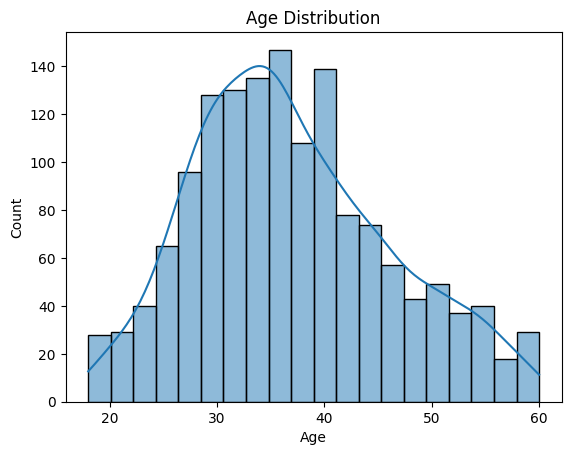

In [42]:
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()


Explanation

sns.histplot() creates a histogram to show the distribution of ages
bins=20 divides the data into 20 groups
kde=True adds a smooth curve to show the overall trend
The x-axis shows age, and the y-axis shows the number of employees

Key Observations

Most employees are in the age range of 30 to 40 years
There are fewer very young (under 25) and older employees (above 50)
The distribution is roughly normal (bell-shaped)

Insight

The workforce is mainly made up of mid-career employees
This may influence attrition patterns and experience levels


I created a chart to see the age range of employees, and most are around 30–40 years old.

Most employees are around 30–40 years old, with fewer younger and older employees.

The age distribution helps identify workforce composition. Further segmentation can reveal whether certain age groups are more prone to attrition.

**Business Recommendation:** Use these insights to guide targeted HR interventions and improve employee retention strategies

Give different support to different age groups to help keep employees at all stages of their careers.

Support different age groups differently

Younger employees may need more training, mentorship, and career guidance

Focus on mid-career employees

Since most employees are aged 30–40, provide growth opportunities and promotions to keep them engaged

Retain experienced employees

Offer incentives and recognition to older employees to keep their skills and knowledge in the companany


## Income vs Attrition


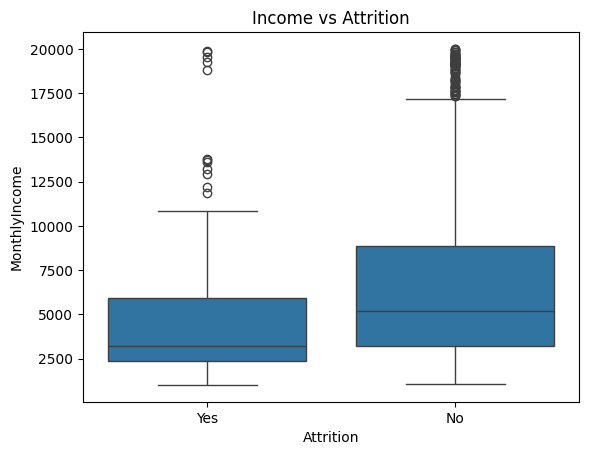

In [43]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Income vs Attrition')
plt.show()


Explanation

This chart compares salaries of employees who stayed (No) and left (Yes)

The box shows the range and spread of incomes

The line in the box shows the median (middle value)

###Key Observations

Employees who left tend to have lower incomes

Employees who stayed generally earn more

There are some high earners in both groups, but most leavers are in lower ranges

###Insight

Lower salary is linked to higher attrition


Employees with lower pay are more likely to leave the company.




###Business Recommendation 

Review salaries for lower-paid employees

Employees with lower income are more likely to leave, so improving pay can help reduce attrition

Offer incentives and rewards

Bonuses, benefits, or salary increases can help keep employees
Ensure fair pay

Make sure employees feel they are paid fairly compared to others in similar roles

Look at the bigger picture

Combine salary improvements with better job satisfaction and work-life balance

## Job Satisfaction vs Attrition


Explanation

sns.countplot() creates a bar chart showing counts for each Job Satisfaction level
x='JobSatisfaction' shows satisfaction levels (e.g., 1 = low, 4 = high)
hue='Attrition' splits each bar into employees who left (Yes) and stayed (No)
This helps compare attrition across satisfaction levels

Key Observations

Employees with lower job satisfaction (1 or 2) tend to have higher attrition
Employees with higher satisfaction (3 or 4) are more likely to stay
The number of employees staying is higher across all levels

Insight

Job satisfaction appears to be an important factor influencing attrition
Lower satisfaction may increase the likelihood of employees leaving


Employees with lower job satisfaction are more likely to leave the company.

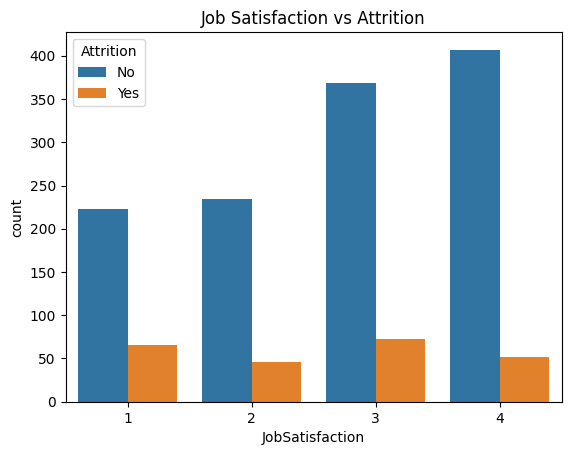

In [44]:
sns.countplot(data=df, x='JobSatisfaction', hue='Attrition')
plt.title('Job Satisfaction vs Attrition')
plt.show()


## Job Satisfaction vs Attrition


### Explanation

The chart compares employee attrition across different job satisfaction levels (1 = low, 4 = high).

### Key Observations

- Employees with **low job satisfaction (level 1)** have a noticeable number of employees leaving  
- As job satisfaction increases, the number of employees who **stay (No)** increases significantly  
- Even at higher satisfaction levels (3 and 4), some employees still leave, but fewer compared to those who stay  
- Overall, the number of employees staying is higher at all satisfaction levels  

### Insight

- Higher job satisfaction is linked to **lower attrition**  
- Job satisfaction is an important factor influencing whether employees leave the company  

### 

Employees who are less satisfied with their jobs are more likely to leave.

**Insight:** The distribution shows a clear imbalance in attrition. This highlights the importance of focusing on retention strategies for high-risk groups.


**Business Recommendation:** Use these insights to guide targeted HR interventions and improve employee retention strategies.


## Work-Life Balance vs Attrition


Explanation

sns.countplot() shows the count of employees for each Work-Life Balance level
x='WorkLifeBalance' represents balance levels (1 = low, 4 = high)
hue='Attrition' splits each bar into employees who left (Yes) and stayed (No)
This helps compare attrition across different balance levels

Key Observations

Employees with low work-life balance (1 or 2) tend to have higher attrition
Employees with better work-life balance (3 or 4) are more likely to stay
Across all levels, more employees stay than leave

Insight

Work-life balance appears to influence employee retention
Poor work-life balance may increase the likelihood of employees leaving


Employees with a poor work-life balance are more likely to leave the company.

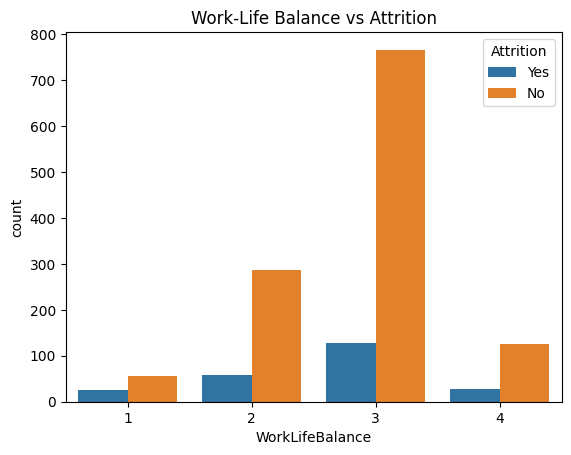

In [45]:
sns.countplot(data=df, x='WorkLifeBalance', hue='Attrition')
plt.title('Work-Life Balance vs Attrition')
plt.show()


## Work-Life Balance vs Attrition

### Explanation

The chart shows the number of employees who stayed (`No`) and left (`Yes`) across different work-life balance levels (1 = low, 4 = high).

### Key Observations

- Most employees have a **work-life balance level of 3**, with the highest number staying  
- Employees with **low work-life balance (level 1)** have fewer employees overall, but some still leave  
- Attrition is **higher at lower balance levels (1 and 2)** compared to higher levels  
- At higher levels (3 and 4), more employees stay than leave  

### Insight

- Better work-life balance is associated with **lower attrition**  
- Employees with poor work-life balance are more likely to leave  


Employees with a better work-life balance are more likely to stay, while those with poor balance are more likely to leave.

**Insight:** The distribution shows a clear imbalance in attrition. This highlights the importance of focusing on retention strategies for high-risk groups.


**Business Recommendation:** Use these insights to guide targeted HR interventions and improve employee retention strategies.


## Department Analysis


Explanation

sns.countplot() shows the number of employees in each department
x='Department' displays different departments
hue='Attrition' separates employees who left (Yes) and stayed (No)
plt.xticks(rotation=45) rotates labels for better readability

Key Observations

Some departments have higher attrition than others
The department with more employees tends to have more cases of attrition
In all departments, more employees stay than leave

Insight

Attrition varies by department, suggesting that work environment or job roles may influence turnover


Some departments have more employees leaving than others, but most employees still stay overall.

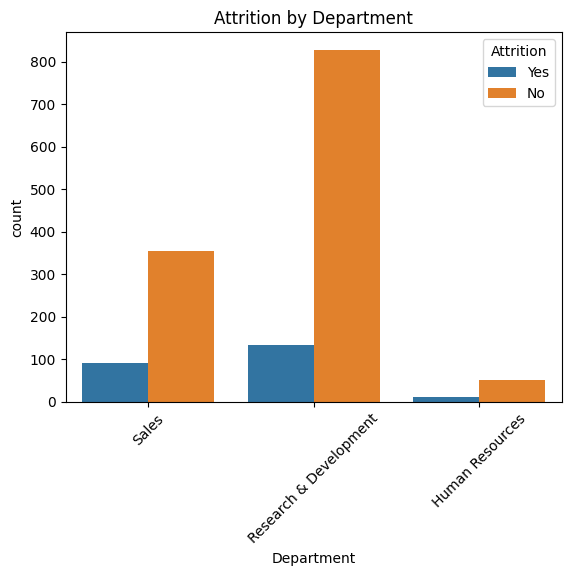

In [46]:
sns.countplot(data=df, x='Department', hue='Attrition')
plt.xticks(rotation=45)
plt.title('Attrition by Department')
plt.show()


## Attrition by Department

### Explanation

The chart shows the number of employees who stayed (`No`) and left (`Yes`) in each department.

### Key Observations

- **Research & Development** has the highest number of employees and the highest number of employees leaving  
- **Sales** also shows a noticeable level of attrition  
- **Human Resources** has the lowest number of employees and the lowest attrition  
- In all departments, more employees stay than leave  

### Insight

- Departments with more employees tend to have higher attrition  
- Attrition may be influenced by the type of work or environment in each department  


Some departments, especially Research & Development and Sales, have more employees leaving, but most employees still stay overall.

**Insight:** The distribution shows a clear imbalance in attrition. This highlights the importance of focusing on retention strategies for high-risk groups.


**Business Recommendation:** Use these insights to guide targeted HR interventions and improve employee retention strategies.


## Correlation Analysis


Explanation

df.corr() calculates the correlation between numerical variables
numeric_only=True ensures only numerical columns are included
sns.heatmap() creates a visual representation of correlations
Colours show the strength of relationships:
Red = strong positive correlation
Blue = strong negative correlation
Light colours = weak or no correlation

Key Observations

Most variables show weak correlations with each other
Some variables (e.g., years-related features) may have moderate positive relationships
No extremely strong correlations are visible

Insight

The dataset does not have many highly correlated features
This suggests that most variables provide unique information


I created a heatmap to see how different variables are related, and most of them are not strongly related.

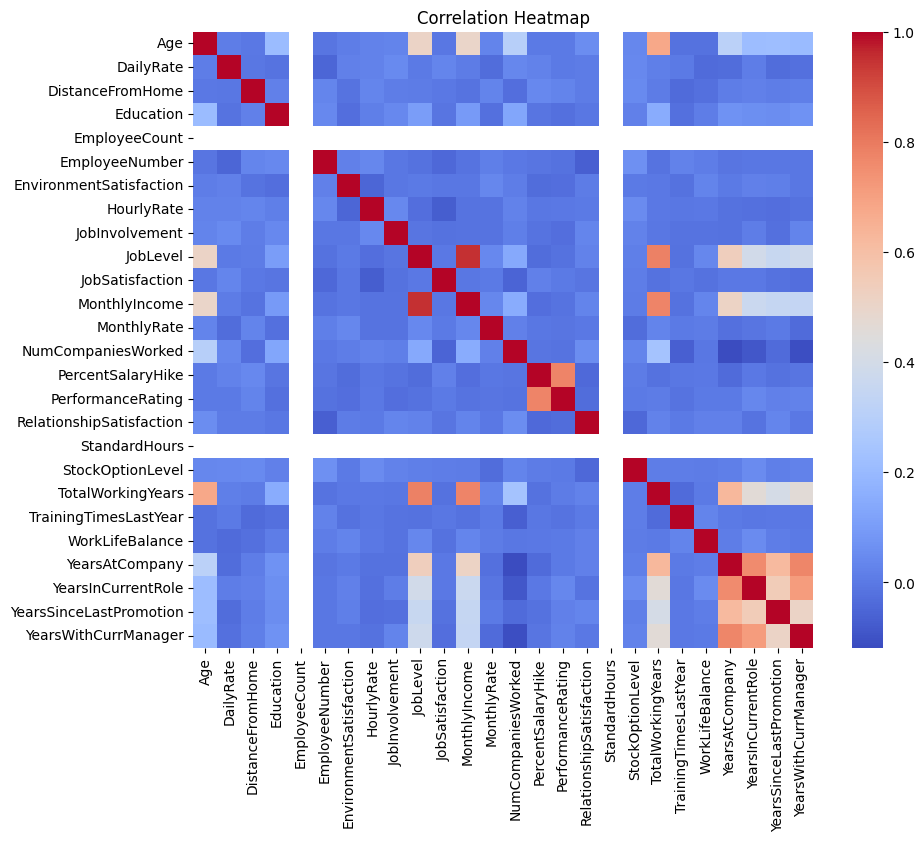

In [47]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


## Correlation Heatmap


### Explanation

The heatmap shows the relationship between numerical variables in the dataset.  
Darker red colours indicate stronger positive relationships, while blue indicates weak or negative relationships.


### Key Observations

- Most variables have **weak correlations** (light blue), meaning they are not strongly related  
- **YearsAtCompany, YearsInCurrentRole, YearsWithCurrManager, and YearsSinceLastPromotion** show **strong positive correlations** with each other  
- **MonthlyIncome** is moderately correlated with **JobLevel** and **TotalWorkingYears**  
- Some columns like `EmployeeCount` and `StandardHours` show no variation and are not useful  

### Insight

- Experience-related features are closely linked, which is expected  
- Most variables provide **independent information**, which is good for analysis and modelling  
- Highly correlated features may need to be handled carefully to avoid redundancy  


Most variables are not strongly related, but experience-related features are closely connected.

**Insight:** Correlation analysis highlights relationships between variables. Strong correlations help identify key drivers influencing attrition.


**Business Recommendation:** Focus retention strategies on variables with the strongest relationships to attrition to maximise impact.


## Key Insights

- Attrition is imbalanced but significant
- Lower satisfaction correlates with higher attrition
- Income shows partial influence
- Work-life balance is a strong factor
- Some departments show higher attrition patterns

These findings support the project hypotheses and business requirements.



In conclusion

## Exploratory Data Analysis (EDA) Summary


The dataset was explored to understand its structure, data quality, and key patterns related to employee attrition.

### Key Findings


- The dataset contains **1470 rows and multiple features**, with no missing values after cleaning  
- Most employees (**1233**) stayed, while a smaller number (**237**) left, showing **class imbalance**  
- The majority of employees are aged between **30 and 40 years**  
- Employees with **lower job satisfaction and poor work-life balance** are more likely to leave  
- **Research & Development and Sales** departments have higher attrition compared to Human Resources  
- Experience-related features (e.g., YearsAtCompany, TotalWorkingYears) are positively correlated  

### Insight


- Employee attrition is influenced by **job satisfaction, work-life balance, and department**  
- Most variables are not strongly correlated, meaning they provide **useful and unique information**  


I explored the dataset, found patterns in employee behaviour, and identified key factors that may influence why employees leave.

## Analysis


The exploratory data analysis (EDA) was conducted using statistical summaries and visualisations to identify patterns in the dataset.


### Key Analysis from Visualisations


- The **attrition distribution** shows that most employees stayed (1233), while a smaller number left (237), indicating class imbalance  
- The **age distribution** shows that most employees are between 30 and 40 years old, suggesting a mid-career workforce  
- The **job satisfaction chart** indicates that employees with lower satisfaction are more likely to leave  
- The **work-life balance chart** shows that poor work-life balance is linked to higher attrition  
- The **department analysis** reveals that Research & Development and Sales have higher attrition compared to Human Resources  

### Correlation Analysis


- The heatmap shows that most variables have weak relationships  
- Experience-related features such as `YearsAtCompany`, `YearsInCurrentRole`, and `YearsWithCurrManager` are strongly correlated  
- `MonthlyIncome` is moderately related to `JobLevel` and `TotalWorkingYears`  

### Overall Insight


- Employee attrition is influenced by **job satisfaction, work-life balance, and department**  
- Most variables provide unique information, which is useful for further analysis or modelling  


The analysis shows that employees are more likely to leave when they are less satisfied, have poor work-life balance, or work in certain departments.